23070521135 - Sharvayu Zade


In [1]:
# Install yfinance to fetch stock data
!pip install yfinance --quiet

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

In [3]:
# Define the stock ticker and date range
TICKER = 'AAPL' # Apple Inc.
START_DATE = '2010-01-01'
END_DATE = '2023-01-01'

# Download data
df = yf.download(TICKER, start=START_DATE, end=END_DATE)

# Display the first few rows of the data
print(f"Downloaded data for {TICKER} from {START_DATE} to {END_DATE}.")
display(df.head())

# Use only the 'Close' price for prediction
data = df['Close'].values.reshape(-1, 1)

# Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print("\nScaled data snippet:")
display(scaled_data[:5])

/tmp/ipykernel_6055/1472712790.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

Downloaded data for AAPL from 2010-01-01 to 2023-01-01.


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.400960,6.415616,6.352208,6.383613,493729600
2010-01-05,6.412027,6.448218,6.378229,6.418608,601904800
2010-01-06,6.310036,6.437451,6.303456,6.412028,552160000
2010-01-07,6.298370,6.340842,6.252608,6.333365,477131200
2010-01-08,6.340244,6.340843,6.252909,6.289996,447610800



Scaled data snippet:


array([[0.00381776],
       [0.00388208],
       [0.00328926],
       [0.00322145],
       [0.00346484]])

In [4]:
# Function to create sequences for LSTM
def create_sequences(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Define time step (number of previous days to consider for prediction)
TIME_STEP = 60

# Create features (X) and target (y)
X, y = create_sequences(scaled_data, TIME_STEP)

# Split data into training and testing sets
# We'll use 80% for training and 20% for testing
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

# Reshape input to be [samples, time_steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (2569, 60, 1)
Shape of y_train: (2569,)
Shape of X_test: (643, 60, 1)
Shape of y_test: (643,)


In [5]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(TIME_STEP, 1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, batch_size=32, epochs=50, validation_split=0.1, verbose=1)

print("Model training complete.")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.0010 - val_loss: 3.8507e-04
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 4.1459e-05 - val_loss: 4.0530e-04
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - loss: 3.7669e-05 - val_loss: 3.1040e-04
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 3.9986e-05 - val_loss: 4.4554e-04
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 3.5444e-05 - val_loss: 2.4717e-04
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 3.4977e-05 - val_loss: 2.4124e-04
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 3.1487e-05 - val_loss: 2.6611e-04
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 2.8167e-05 - val_loss: 2.5039e-04
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - loss: 2.6790e-05 - val_loss: 2.8378e-04
Epoch 10/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 2.6845e-05 - val_loss: 2.5445e-04
Epoch 11/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 2.6256e-

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


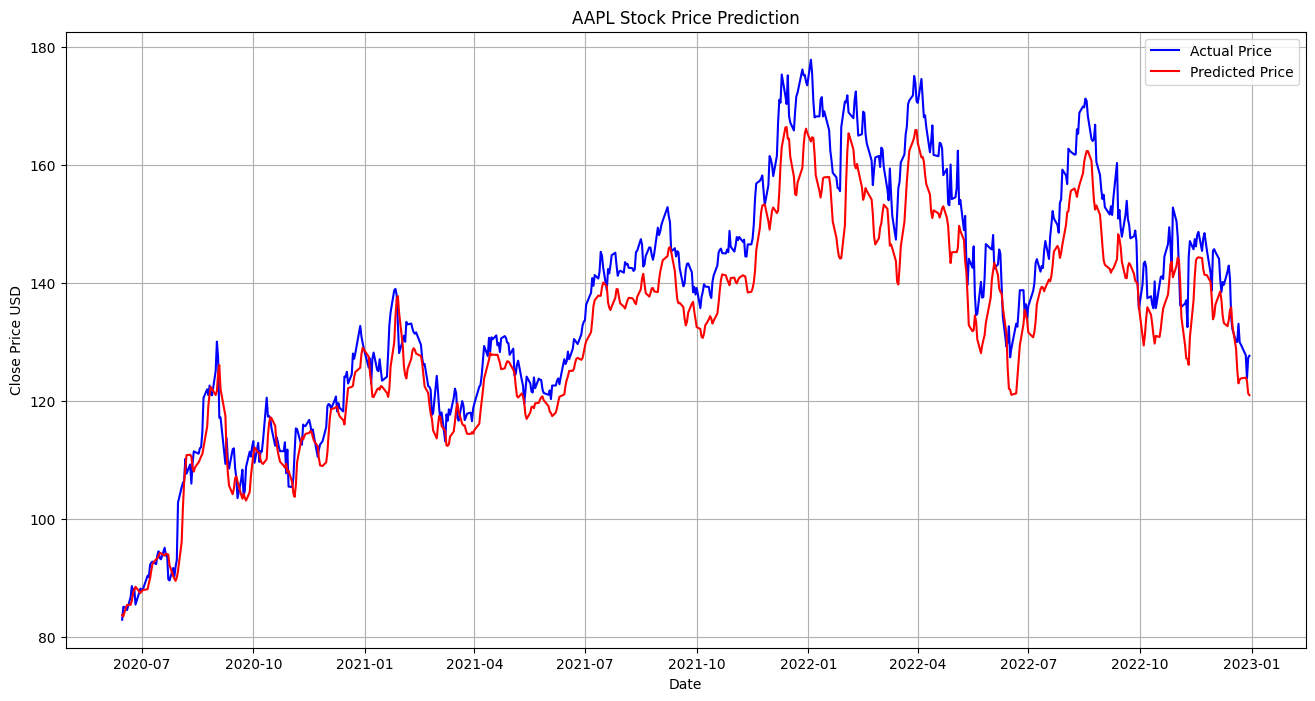

In [6]:
# Make predictions on the test set
test_predictions = model.predict(X_test)

# Inverse transform the predictions and y_test to get actual prices
test_predictions_rescaled = scaler.inverse_transform(test_predictions)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Prepare actual values for plotting (from the original DataFrame)
# The 'Close' prices used for testing start after the training data and TIME_STEP offset
# This variable was causing issues, removing it for a clearer approach.
# actual_prices_plot = df['Close'].values[len(df) - len(y_test_rescaled) - TIME_STEP + 1:]

# The dates for plotting should correspond to the actual y_test values.
# y_test corresponds to data[TIME_STEP + train_size:] in the original scaled_data.
# So, the dates should be from df.index starting at TIME_STEP + train_size.
dates_for_plot = df.index[TIME_STEP + train_size:]

# Visualize the results
plt.figure(figsize=(16, 8))
plt.title(f'{TICKER} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price USD')

plt.plot(dates_for_plot, y_test_rescaled, label='Actual Price', color='blue')
plt.plot(dates_for_plot, test_predictions_rescaled, label='Predicted Price', color='red')
plt.legend()
plt.grid(True)
plt.show()